<a href="https://colab.research.google.com/github/prodigal94/food-safe-bots/blob/main/Week4_CLUSTERING_FineTuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql import SparkSession

# Initialize Spark
spark = SparkSession.builder \
    .appName("BDA_Project_Week4_Clustering") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .getOrCreate()

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = spark.read.parquet("/content/drive/MyDrive/Parquet/02_AgriTrade_ValueOnly.parquet")

In [4]:
# Filter for import-related elements
import_elements = [
    row.Element for row in df.select("Element").distinct().collect()
    if row.Element is not None and "import" in row.Element.lower()
]

import_element = import_elements[0] if len(import_elements) > 0 else None
if import_element:
    df_trade = df.filter(F.col("Element") == import_element)
else:
    df_trade = df

print(f"Total records after filtering for imports: {df_trade.count():,}")

Total records after filtering for imports: 2,584,844


In [5]:
# Setup Window specification for YoY calculation
window_spec = Window.partitionBy("Area", "Item").orderBy("Year")

df_features = df_trade.withColumn(
    "Value_prev", F.lag("Value").over(window_spec)
)

df_features = df_features.withColumn(
    "YoY_Change",
    F.when(
        F.col("Value_prev").isNull() | (F.col("Value_prev") == 0), 0
    ).otherwise(
        ((F.col("Value") - F.col("Value_prev")) / F.col("Value_prev")) * 100
    )
).na.fill(0)

In [6]:
# Aggregate features by Area and Year
area_year_features = df_features.groupBy("Area", "Year").agg(
    F.countDistinct("Item").alias("num_products"),
    F.sum("Value").alias("total_volume"),
    F.avg("YoY_Change").alias("avg_growth")
).na.fill(0).filter(F.col("total_volume") > 0)

print(f"Final records available for clustering: {area_year_features.count():,}")
area_year_features.show(5)

Final records available for clustering: 11,904
+-------------------+----+------------+------------+------------------+
|               Area|Year|num_products|total_volume|        avg_growth|
+-------------------+----+------------+------------+------------------+
|             Angola|1979|          78|   2731547.0| 33.50274490225309|
|             Angola|1987|          99|   2822339.0| 80.46926497028974|
|Antigua and Barbuda|1995|         107|    516409.0|20.648089477221376|
|Antigua and Barbuda|2017|         314|  1259977.03| 70.56242981042807|
|          Argentina|2010|         292| 6.4724423E7| 843.8836402500788|
+-------------------+----+------------+------------+------------------+
only showing top 5 rows


In [7]:
from pyspark.ml.feature import VectorAssembler, StandardScaler

# Step 1: Assemble features into a single Vector
feature_cols = ["num_products", "total_volume", "avg_growth"]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features_unscaled"
)

df_vector = assembler.transform(area_year_features)

In [8]:
# Step 2: Apply StandardScaler
scaler = StandardScaler(
    inputCol="features_unscaled",
    outputCol="features",
    withStd=True,
    withMean=True
)

scaler_model = scaler.fit(df_vector)
df_scaled = scaler_model.transform(df_vector)

print("Feature scaling is complete! The dataset is now mathematically ready for distance-based clustering.")

Feature scaling is complete! The dataset is now mathematically ready for distance-based clustering.


In [9]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator = ClusteringEvaluator(
    predictionCol="prediction",
    featuresCol="features",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)

In [10]:
# Initialize tracking variables
best_k = 2
best_score = -1.0
k_values = [2, 3, 4, 5, 6, 7, 8]
scores = []

print("=== STARTING KMEANS HYPERPARAMETER TUNING ===")
print("Evaluating different values of 'k'...\n")

for k in k_values:
    # 1. Initialize KMeans with the current k
    kmeans_temp = KMeans(k=k, featuresCol="features", predictionCol="prediction", seed=42)

    # 2. Train the model
    model_temp = kmeans_temp.fit(df_scaled)

    # 3. Generate predictions
    predictions_temp = model_temp.transform(df_scaled)

    # 4. Calculate silhouette score
    score = evaluator.evaluate(predictions_temp)
    scores.append(score)

    print(f"[*] Tested Model (k={k}) -> Silhouette Score: {score:.4f}")

    # 5. Track the best model
    if score > best_score:
        best_score = score
        best_k = k

=== STARTING KMEANS HYPERPARAMETER TUNING ===
Evaluating different values of 'k'...

[*] Tested Model (k=2) -> Silhouette Score: 0.4976
[*] Tested Model (k=3) -> Silhouette Score: 0.5124
[*] Tested Model (k=4) -> Silhouette Score: 0.6788
[*] Tested Model (k=5) -> Silhouette Score: 0.7051
[*] Tested Model (k=6) -> Silhouette Score: 0.7634
[*] Tested Model (k=7) -> Silhouette Score: 0.6433
[*] Tested Model (k=8) -> Silhouette Score: 0.6462


In [11]:
print(f"The algorithm determined that the optimal number of clusters is: k = {best_k}")
print(f"This configuration achieved the highest Silhouette Score: {best_score:.4f}")

The algorithm determined that the optimal number of clusters is: k = 6
This configuration achieved the highest Silhouette Score: 0.7634


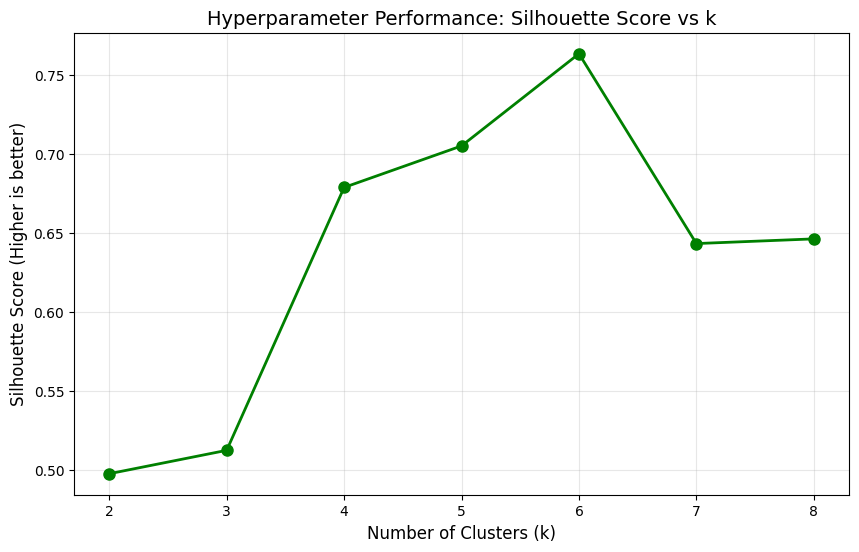

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(k_values, scores, marker='o', linestyle='-', color='g', linewidth=2, markersize=8)
plt.title('Hyperparameter Performance: Silhouette Score vs k', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score (Higher is better)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
# Initialize the final KMeans model with the winning k
final_kmeans = KMeans(
    k=best_k,
    featuresCol="features",
    predictionCol="prediction",
    seed=42
)

# Fit the final optimized model
best_model = final_kmeans.fit(df_scaled)
print("Final optimized model has been trained successfully")

Final optimized model has been trained successfully!


In [14]:
# Extract the cluster centers directly from the PySpark model
centers = best_model.clusterCenters()

print("=== FINAL CLUSTER CENTERS ===")
for i, center in enumerate(centers):
    print(f"Cluster {i}:")
    print(f"  - Scaled num_products: {center[0]:.4f}")
    print(f"  - Scaled total_volume: {center[1]:.4f}")
    print(f"  - Scaled avg_growth:   {center[2]:.4f}\n")

=== FINAL CLUSTER CENTERS ===
Cluster 0:
  - Scaled num_products: 1.6657
  - Scaled total_volume: 1.9707
  - Scaled avg_growth:   -0.0519

Cluster 1:
  - Scaled num_products: -0.8530
  - Scaled total_volume: -0.2215
  - Scaled avg_growth:   -0.0336

Cluster 2:
  - Scaled num_products: 1.8932
  - Scaled total_volume: 10.7863
  - Scaled avg_growth:   -0.0002

Cluster 3:
  - Scaled num_products: -1.0702
  - Scaled total_volume: -0.2268
  - Scaled avg_growth:   64.6990

Cluster 4:
  - Scaled num_products: -0.0580
  - Scaled total_volume: 0.0334
  - Scaled avg_growth:   10.6504

Cluster 5:
  - Scaled num_products: 0.8003
  - Scaled total_volume: -0.0818
  - Scaled avg_growth:   -0.0254



In [16]:
# Get the final predictions
final_predictions = best_model.transform(df_scaled)

# Count how many data points ended up in each cluster
cluster_counts = final_predictions.groupBy("prediction").count().orderBy("prediction").collect()

print("=== CLUSTER POPULATION ANALYSIS ===")
for row in cluster_counts:
    cluster_id = row['prediction']
    count = row['count']
    print(f"Cluster {cluster_id} contains {count} records.")

    # Flag Anomalies (Clusters with fewer than 50 records in a large dataset)
    if count < 50:
        print(f"ANOMALY DETECTED: Cluster {cluster_id} is a micro-cluster! These records exhibit extreme outlier behavior (e.g. massive trade disruptions or severe dependencies).")

=== CLUSTER POPULATION ANALYSIS ===
Cluster 0 contains 520 records.
Cluster 1 contains 6067 records.
Cluster 2 contains 69 records.
Cluster 3 contains 2 records.
ANOMALY DETECTED: Cluster 3 is a micro-cluster! These records exhibit extreme outlier behavior (e.g. massive trade disruptions or severe dependencies).
Cluster 4 contains 22 records.
ANOMALY DETECTED: Cluster 4 is a micro-cluster! These records exhibit extreme outlier behavior (e.g. massive trade disruptions or severe dependencies).
Cluster 5 contains 5224 records.


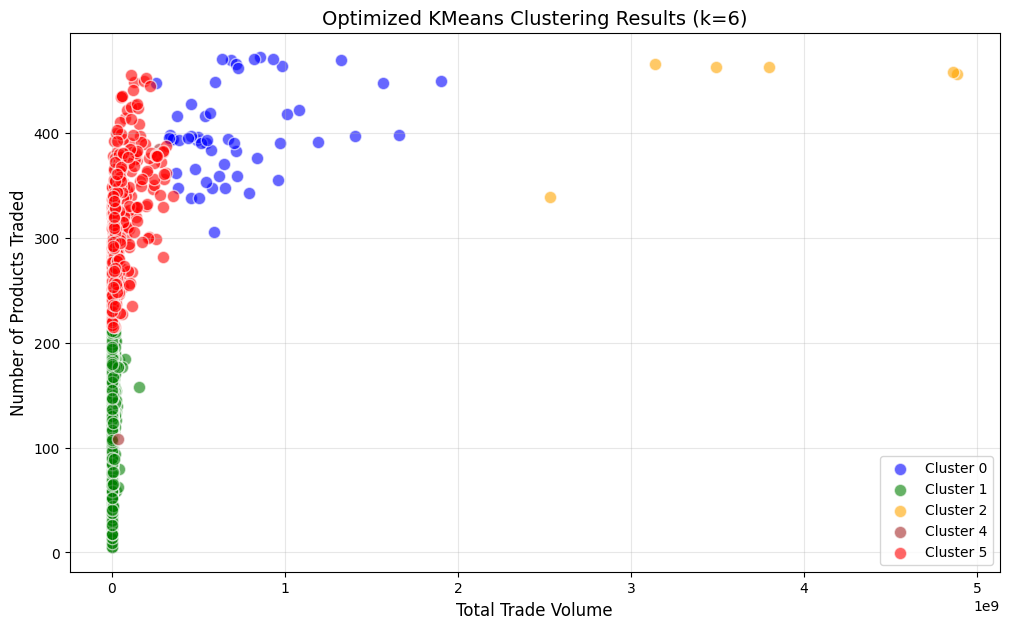

In [17]:
# Collect a representative sample to avoid overwhelming the plot
sample_fraction = min(0.1, 5000 / final_predictions.count())
sample_data = final_predictions.select("total_volume", "num_products", "prediction").sample(False, sample_fraction, seed=42).toPandas()

# Plot the clusters
plt.figure(figsize=(12, 7))
colors = ["blue", "green", "orange", "purple", "brown", "red", "pink", "gray", "olive"]

for cluster_id in sorted(sample_data['prediction'].unique()):
    cluster_subset = sample_data[sample_data['prediction'] == cluster_id]
    plt.scatter(
        cluster_subset['total_volume'],
        cluster_subset['num_products'],
        c=colors[cluster_id % len(colors)],
        alpha=0.6,
        edgecolors='w',
        s=80,
        label=f"Cluster {cluster_id}"
    )

plt.xlabel("Total Trade Volume", fontsize=12)
plt.ylabel("Number of Products Traded", fontsize=12)
plt.title(f"Optimized KMeans Clustering Results (k={best_k})", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
# Define the output path
modelPath = "./kmeans-tuned-model"

# Writing the best model to disk using the exact PySpark Save API
best_model.write().overwrite().save(modelPath)

print(f"Successfully saved the tuned clustering model to: {modelPath}")

Successfully saved the tuned clustering model to: ./kmeans-tuned-model
